In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
data = pd.read_csv("../datasets/Exam_Score_Prediction.csv")

In [28]:
data.head(10)

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7
5,6,23,male,b.tech,3.48,65.4,yes,4.2,good,mixed,low,moderate,58.2
6,7,17,female,b.tech,1.35,69.0,yes,7.4,average,online videos,high,hard,53.7
7,8,22,male,b.sc,5.48,51.1,yes,8.2,poor,self-study,low,moderate,47.3
8,9,18,other,bca,2.89,92.0,yes,6.6,poor,self-study,low,easy,44.9
9,10,17,male,bba,6.77,44.8,yes,9.8,average,group study,high,moderate,77.7


In [29]:
data.columns

Index(['student_id', 'age', 'gender', 'course', 'study_hours',
       'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality',
       'study_method', 'facility_rating', 'exam_difficulty', 'exam_score'],
      dtype='object')

In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  object 
 3   course            20000 non-null  object 
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  object 
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  object 
 9   study_method      20000 non-null  object 
 10  facility_rating   20000 non-null  object 
 11  exam_difficulty   20000 non-null  object 
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 2.0+ MB


### Insight

There are no null values in dataset

We have 5 numeric features: ['age', 'study_hours', 'class_attendance', 'sleep_hours', 'study_sleep_ratio']

We have 7 categorical features: ['gender', 'course', 'study_method', 'internet_access', 'sleep_quality', 'facility_rating', 'exam_difficulty']

In [31]:
data.describe()

,student_id,age,study_hours,class_attendance,sleep_hours,exam_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000
mean,10000.504600,20.473300,4.007604,70.017365,7.00856,62.513225
std,5773.654959,2.284458,2.308313,17.282262,1.73209,18.908491
min,1.000000,17.000000,0.080000,40.600000,4.10000,19.599000
25%,5000.750000,18.000000,2.000000,55.100000,5.50000,48.800000
50%,10000.500000,20.000000,4.040000,69.900000,7.00000,62.600000
75%,15000.250000,22.000000,6.000000,85.000000,8.50000,76.300000
max,20001.000000,24.000000,7.910000,99.400000,9.90000,100.000000


### Insight

From the summary statistics:
- average exam score is about **62.5** with a median of **62.6**;
- average study time is about **4 hours**;
- average class attendance is about **70%**;
- average sleep is about **7 hours**.

Text(0.5, 0, 'Exam score')

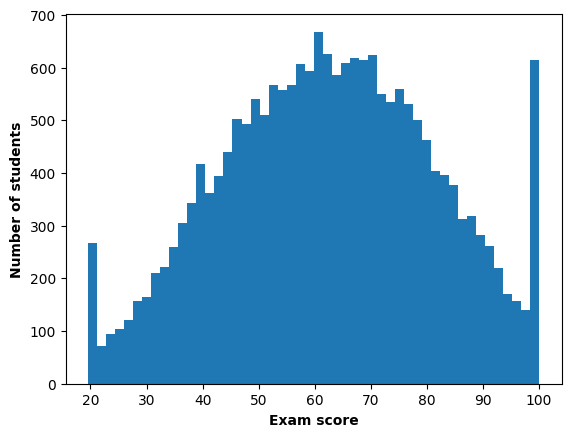

In [32]:
data['exam_score'].hist(bins=50, grid=False)

plt.ylabel("Number of students", fontweight="bold")
plt.xlabel("Exam score", fontweight="bold")

### Insight

Exam score distribution is centered around **60** and spans the range from **20 to 100**

Text(0, 0.5, 'Average exam score')

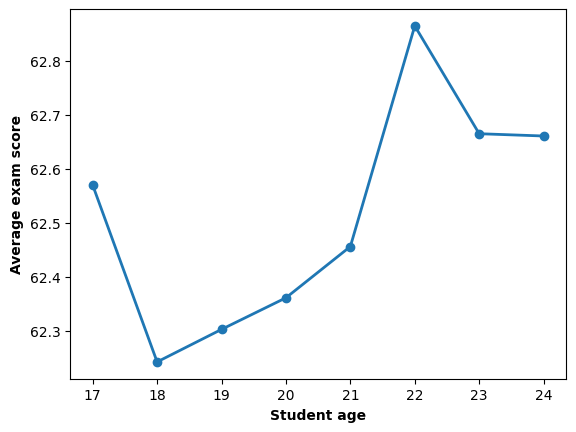

In [33]:
avg_score_for_age = data.groupby('age')['exam_score'].mean()
plt.plot(avg_score_for_age.index, avg_score_for_age.values, linewidth=2, marker='o')

plt.xlabel("Student age", fontweight="bold")
plt.ylabel("Average exam score", fontweight="bold")

### Insight

Students of different ages achieve similar exam scores

Text(0.5, 0, 'Gender')

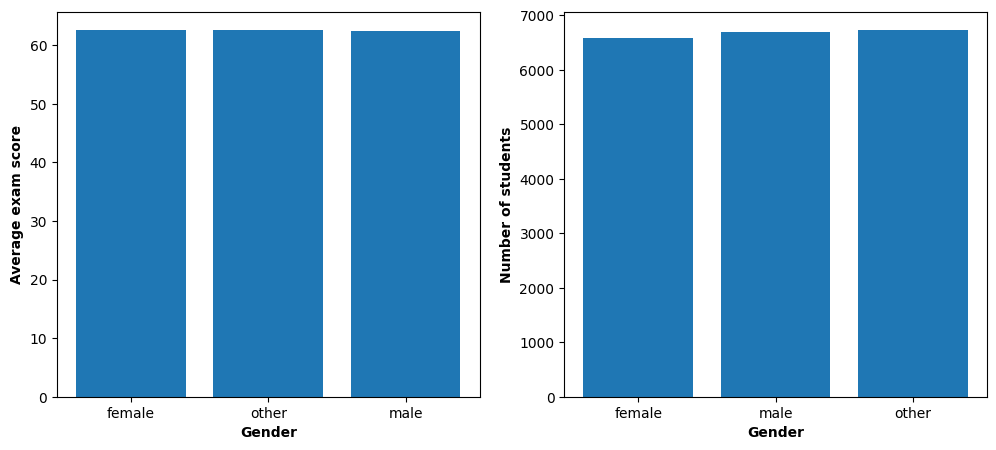

In [34]:
avg_score_for_gender = data.groupby('gender')['exam_score'].mean().sort_values(ascending=False)
gender_count = data.groupby('gender')['student_id'].count()

figure, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

ax = axes[0]
ax.bar(avg_score_for_gender.index, avg_score_for_gender.values)
ax.set_ylabel("Average exam score", fontweight="bold")
ax.set_xlabel("Gender", fontweight="bold")

ax = axes[1]
ax.bar(gender_count.index, gender_count.values)
ax.set_ylabel("Number of students", fontweight="bold")
ax.set_xlabel("Gender", fontweight="bold")

### Insight

Exam scores are similar across genders

Sample sizes are also close to each other

Text(0, 0.5, 'Numebr of students')

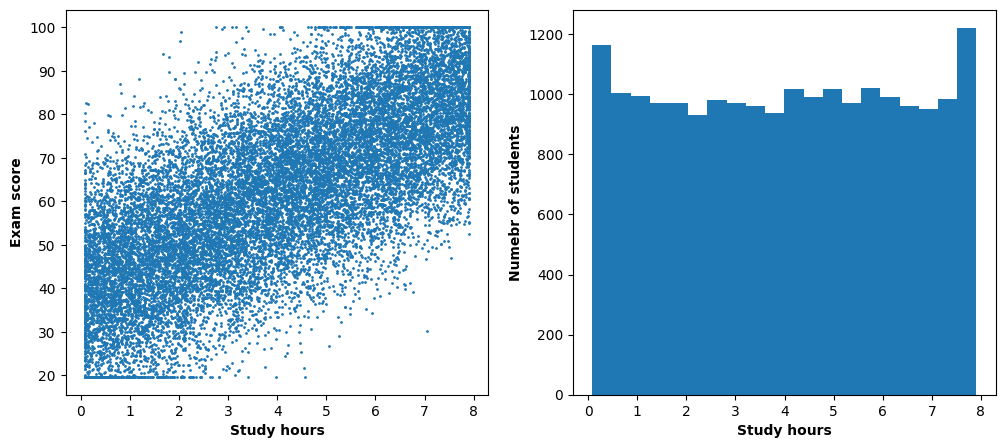

In [35]:
figure, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

ax = axes[0]
ax.scatter(data['study_hours'], data['exam_score'], s=1)
ax.set_xlabel("Study hours", fontweight="bold")
ax.set_ylabel("Exam score", fontweight="bold")

ax = axes[1]
ax.hist(data['study_hours'], bins=20)
ax.set_xlabel("Study hours", fontweight="bold")
ax.set_ylabel("Numebr of students", fontweight="bold")

### Insight

There appears to be a roughly linear relationship between study hours and exam score

In [36]:
data['internet_access'].value_counts()

internet_access
yes    16988
no      3012
Name: count, dtype: int64

In [37]:
data.groupby(['internet_access'])['exam_score'].mean()

internet_access
no     62.864663
yes    62.450914
Name: exam_score, dtype: float64

### Insight

Students without internet access show slightly higher exam scores, although this group is much smaller, which may affect the result

In [38]:
data['course'].value_counts()

course
bca        2902
ba         2896
b.sc       2878
b.com      2864
bba        2836
diploma    2826
b.tech     2798
Name: count, dtype: int64

Text(0, 0.5, 'Exam score')

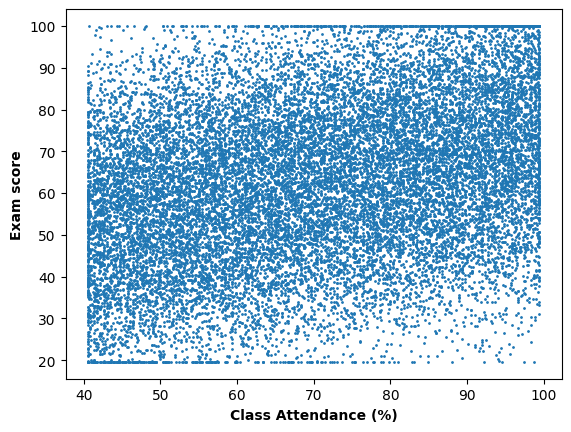

In [39]:
plt.scatter(data['class_attendance'], data['exam_score'], s=1)

plt.xlabel("Class Attendance (%)", fontweight="bold")
plt.ylabel("Exam score", fontweight="bold")

### Insight

Here we also can see smth that looks like linear relationship

Text(0, 0.5, 'Average exam score')

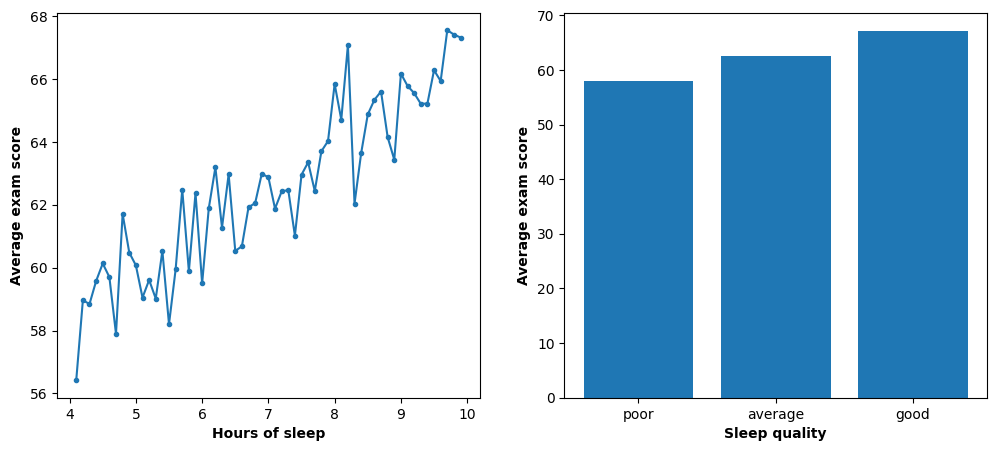

In [40]:
avg_score_depends_on_sleep_hours = data.groupby('sleep_hours')['exam_score'].mean()
avg_score_depends_on_sleep_quality = data.groupby('sleep_quality')['exam_score'].mean().sort_values()

figure, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

ax = axes[0]
ax.plot(avg_score_depends_on_sleep_hours.index, avg_score_depends_on_sleep_hours.values, linewidth=1.5, marker='o', markersize=3)
ax.set_xlabel("Hours of sleep", fontweight="bold")
ax.set_ylabel("Average exam score", fontweight="bold")

ax = axes[1]
ax.bar(avg_score_depends_on_sleep_quality.index, avg_score_depends_on_sleep_quality.values)
ax.set_xlabel("Sleep quality", fontweight="bold")
ax.set_ylabel("Average exam score", fontweight="bold")

### Insight

Sleep duration and sleep quality appear to strongly influence exam scores

In [41]:
data.groupby("sleep_quality")["sleep_hours"].max(), data.groupby("sleep_quality")["sleep_hours"].min()

(sleep_quality
 average    9.9
 good       9.9
 poor       9.9
 Name: sleep_hours, dtype: float64,
 sleep_quality
 average    4.1
 good       4.1
 poor       4.1
 Name: sleep_hours, dtype: float64)

Text(0, 0.5, 'Average exam score')

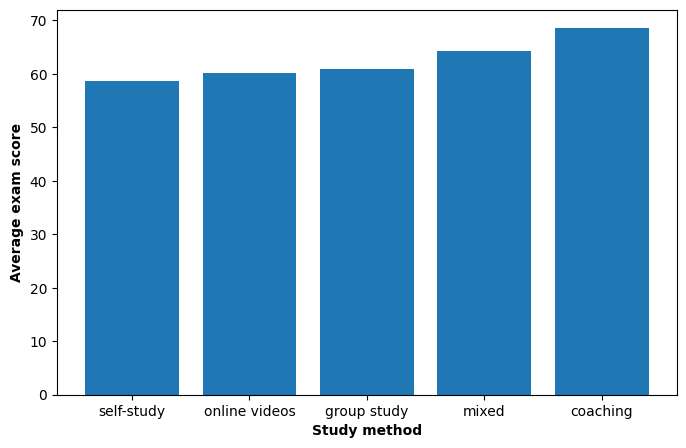

In [42]:
avg_score_depends_on_study_method = data.groupby('study_method')['exam_score'].mean().sort_values()

plt.figure(figsize=(8, 5))
plt.bar(avg_score_depends_on_study_method.index, avg_score_depends_on_study_method.values)

plt.xlabel("Study method", fontweight="bold")
plt.ylabel("Average exam score", fontweight="bold")

### Insight

The coaching method has the highest average exam score, while self-study has the lowest

Text(0, 0.5, 'Average exam score')

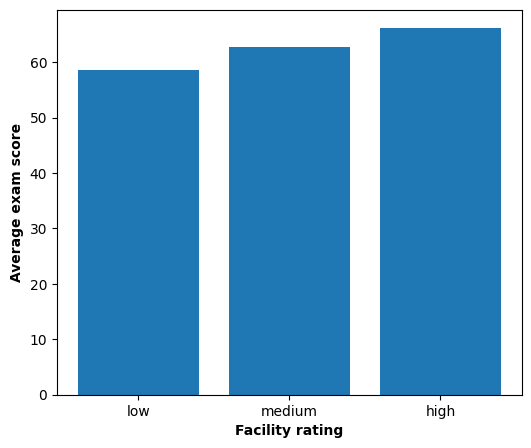

In [43]:
avg_score_depends_on_ficility = data.groupby('facility_rating')['exam_score'].mean().sort_values()

plt.figure(figsize=(6, 5))
plt.bar(avg_score_depends_on_ficility.index, avg_score_depends_on_ficility.values)

plt.xlabel("Facility rating", fontweight="bold")
plt.ylabel("Average exam score", fontweight="bold")

### Insight

The higher the facility rating, the higher the exam score

Text(0, 0.5, 'Average exam score')

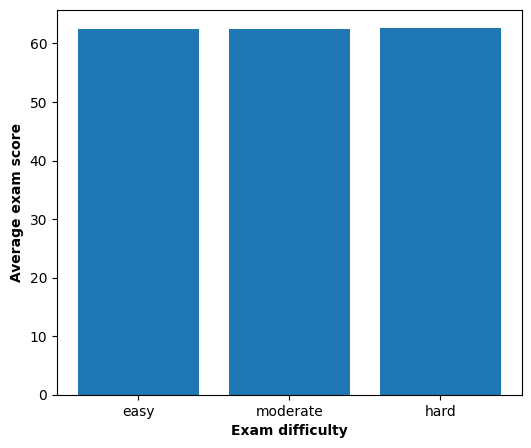

In [44]:
avg_score_depends_on_diffculty = data.groupby('exam_difficulty')['exam_score'].mean().sort_values()

plt.figure(figsize=(6, 5))
plt.bar(avg_score_depends_on_diffculty.index, avg_score_depends_on_diffculty.values)

plt.xlabel("Exam difficulty", fontweight="bold")
plt.ylabel("Average exam score", fontweight="bold")

### Insight

The difficulty of the exam almost does not influence the exam score

In [45]:
data['sleep_study_ratio'] = data['sleep_hours'] / data['study_hours']
data['study_sleep_ratio'] = data['study_hours'] / data['sleep_hours']

<Axes: >

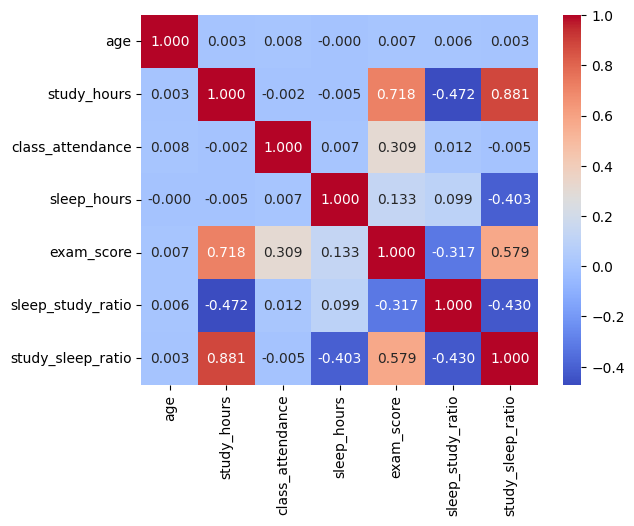

In [46]:
corr = data.drop('student_id', axis=1).corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.3f')

### Insight

Exam score is strongly correlated with study hours, class attendance, and the study–sleep ratio